In [41]:
# Imports
import json
import math
import shutil
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

try:
    import seaborn as sns  # type: ignore
except Exception:
    sns = None

In [42]:
# Configuration (train subset, random sample)
PROJECT_ROOT = Path('.').resolve()
MODELS_DIR = PROJECT_ROOT / 'models'
DATA_DIR = PROJECT_ROOT / 'data'
EVAL_DIR = DATA_DIR / 'asl_alphabet_train' / 'asl_alphabet_train'

# Randomly sample up to 1000 images from the 29 class folders
MAX_IMAGES: int | None = 1000
BATCH_SIZE = 32
SHUFFLE_SEED: int | None = None  # None -> different shuffle each run

# IMPORTANT: fix class index order to match inference (app.py)
CLASS_NAMES_PATH = PROJECT_ROOT / 'class_names.json'
if CLASS_NAMES_PATH.exists():
    class_names = json.loads(CLASS_NAMES_PATH.read_text(encoding='utf-8'))
else:
    class_names = [*list('ABCDEFGHIJKLMNOPQRSTUVWXYZ'), 'del', 'nothing', 'space']

labels = {name: i for i, name in enumerate(class_names)}
id_to_label = {i: name for name, i in labels.items()}

# Models to evaluate
MODEL_SPECS: dict[str, dict[str, str]] = {}
pb_path = MODELS_DIR / 'efficientnet.pb'
if pb_path.exists():
    MODEL_SPECS['efficientnet_pb'] = {'type': 'pb', 'path': str(pb_path)}

if MODELS_DIR.exists():
    for p in sorted(MODELS_DIR.glob('*.h5')):
        if 'efficientnet' in p.stem.lower():
            continue  # Use efficientnet.pb instead of efficientnet.h5
        MODEL_SPECS[p.stem] = {'type': 'h5', 'path': str(p)}

print('Models found:')
for k, spec in MODEL_SPECS.items():
    print(f"  - {k}: {spec['path']} (type={spec['type']})")
print('Eval dir:', EVAL_DIR)
print('Class names path:', CLASS_NAMES_PATH, '(exists=' + str(CLASS_NAMES_PATH.exists()) + ')')
print('Class order (first/last):', class_names[:6], '...', class_names[-6:])
print('Max images:', MAX_IMAGES)
print('Shuffle seed:', SHUFFLE_SEED)

Models found:
  - efficientnet_pb: G:\project ai\models\efficientnet.pb (type=pb)
  - inception: G:\project ai\models\inception.h5 (type=h5)
  - resnet: G:\project ai\models\resnet.h5 (type=h5)
Eval dir: G:\project ai\data\asl_alphabet_train\asl_alphabet_train
Class names path: G:\project ai\class_names.json (exists=True)
Class order (first/last): ['A', 'B', 'C', 'D', 'E', 'F'] ... ['X', 'Y', 'Z', 'del', 'nothing', 'space']
Max images: 1000
Shuffle seed: None


In [43]:
# Dataset helpers
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}

class _SavedModelPredictWrapper:
    def __init__(self, loaded, fn, input_dtype: tf.dtypes.DType | None, input_key: str | None):
        self._loaded = loaded
        self._fn = fn
        self.input_dtype = input_dtype
        self.input_key = input_key

    def predict(self, x: np.ndarray) -> np.ndarray:
        x_tf = tf.convert_to_tensor(x)
        if hasattr(self._fn, 'structured_input_signature'):
            _args, kwargs = self._fn.structured_input_signature
            if kwargs:
                key = self.input_key or next(iter(kwargs.keys()))
                outputs = self._fn(**{key: x_tf})
            else:
                outputs = self._fn(x_tf)
        else:
            outputs = self._fn(x_tf)

        if isinstance(outputs, dict):
            outputs = next(iter(outputs.values()))
        elif isinstance(outputs, (list, tuple)):
            outputs = outputs[0]
        return outputs.numpy()

def load_efficientnet_pb(models_dir: Path) -> _SavedModelPredictWrapper:
    """Load EfficientNet from models/efficientnet.pb + models/variables (SavedModel export)."""
    pb_src = models_dir / 'efficientnet.pb'
    variables_dir = models_dir / 'variables'
    if not pb_src.exists():
        raise FileNotFoundError(f'Missing {pb_src}')
    if not (variables_dir.exists() and variables_dir.is_dir()):
        raise FileNotFoundError(f'Missing SavedModel variables folder: {variables_dir}')

    # TF expects saved_model.pb; create a local copy if needed.
    pb_expected = models_dir / 'saved_model.pb'
    if not pb_expected.exists():
        shutil.copyfile(pb_src, pb_expected)

    loaded = tf.saved_model.load(str(models_dir))
    fn = loaded.signatures.get('serving_default')
    if fn is None:
        fn = getattr(loaded, '__call__', None)
    if fn is None:
        raise ValueError('Loaded SavedModel but found no serving_default signature and no __call__.')

    input_dtype: tf.dtypes.DType | None = None
    input_key: str | None = None
    if hasattr(fn, 'structured_input_signature'):
        _args, kwargs = fn.structured_input_signature
        if kwargs:
            input_key = next(iter(kwargs.keys()))
            spec = kwargs[input_key]
            if hasattr(spec, 'dtype'):
                input_dtype = spec.dtype

    return _SavedModelPredictWrapper(loaded, fn, input_dtype=input_dtype, input_key=input_key)

def get_model_image_size(model) -> tuple[int, int]:
    # EfficientNet pb wrapper doesn't expose input_shape; our app uses 224x224.
    shape = getattr(model, 'input_shape', None)
    if shape is None:
        return (224, 224)
    if isinstance(shape, list):
        shape = shape[0]
    if not shape or len(shape) < 4:
        return (224, 224)
    h, w = shape[1], shape[2]
    if h is None or w is None:
        return (224, 224)
    return (int(h), int(w))

def preprocess_for_model(images: tf.Tensor, model_key: str, model_obj=None) -> tf.Tensor:
    """Match app.py preprocessing.

    - EfficientNet (.pb): dtype-aware, NO /255 (keep 0..255 range)
      - if signature expects uint8 -> cast to uint8
      - else -> float32 (still 0..255)
    - Other models (.h5): float32 + /255
    """
    if model_key == 'efficientnet_pb':
        input_dtype = getattr(model_obj, 'input_dtype', None) if model_obj is not None else None
        if input_dtype == tf.uint8:
            return tf.cast(images, tf.uint8)
        return tf.cast(images, tf.float32)
    images = tf.cast(images, tf.float32)
    return images / 255.0

def _load_and_resize(path: tf.Tensor, image_size: tuple[int, int]) -> tf.Tensor:
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, image_size)
    return img

def make_dataset(
    eval_dir: Path,
    image_size: tuple[int, int],
    batch_size: int,
    shuffle: bool = True,
    shuffle_seed: int | None = None,
    max_images: int | None = None,
    ensure_class_mix: bool = True,
    ) -> tuple[tf.data.Dataset, list[str]]:
    """Build a dataset and (optionally) sample max_images images.

    IMPORTANT: labels are mapped using the fixed `class_names` order (same as app.py),
    not using directory listing order. This avoids class-index drift for folders like
    `del`, `nothing`, and `space`.
    """

    expected_classes = list(class_names)
    class_to_index = {name: i for i, name in enumerate(expected_classes)}

    files_by_class: dict[str, list[str]] = {}
    missing_dirs: list[str] = []
    empty_dirs: list[str] = []
    for class_name in expected_classes:
        class_dir = eval_dir / class_name
        if not class_dir.exists() or not class_dir.is_dir():
            missing_dirs.append(class_name)
            continue
        files = [str(p) for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
        if not files:
            empty_dirs.append(class_name)
            continue
        files_by_class[class_name] = files

    if missing_dirs:
        raise ValueError(f"Missing class folders under {eval_dir}: {missing_dirs}")
    if empty_dirs:
        raise ValueError(f"No images found for class folders: {empty_dirs}")

    rng = np.random.default_rng(shuffle_seed)

    if max_images is None:
        file_strs: list[str] = []
        label_ints: list[int] = []
        for class_name in expected_classes:
            for fp in files_by_class[class_name]:
                file_strs.append(fp)
                label_ints.append(class_to_index[class_name])
        if shuffle:
            order = rng.permutation(len(file_strs))
            file_strs = [file_strs[i] for i in order]
            label_ints = [label_ints[i] for i in order]
    else:
        n = int(max_images)
        if ensure_class_mix:
            cycles, rem = divmod(n, len(expected_classes))
            class_seq: list[str] = []
            for _ in range(cycles):
                class_seq.extend(list(rng.permutation(expected_classes)))
            if rem:
                class_seq.extend(list(rng.permutation(expected_classes))[:rem])
        else:
            class_seq = list(rng.choice(expected_classes, size=n, replace=True))

        file_strs = []
        label_ints = []
        for class_name in class_seq:
            fp = rng.choice(files_by_class[class_name])
            file_strs.append(fp)
            label_ints.append(class_to_index[class_name])

    path_ds = tf.data.Dataset.from_tensor_slices(file_strs)
    label_ds = tf.data.Dataset.from_tensor_slices(label_ints)
    ds_raw = tf.data.Dataset.zip((path_ds, label_ds)).map(
        lambda p, l: (_load_and_resize(p, image_size), l), num_parallel_calls=tf.data.AUTOTUNE
)
    ds_raw = ds_raw.batch(batch_size)
    ds = ds_raw.prefetch(tf.data.AUTOTUNE)
    return ds, expected_classes

def dataset_with_preprocess(ds: tf.data.Dataset, model_key: str, model_obj=None) -> tf.data.Dataset:
    return ds.map(
        lambda x, y: (preprocess_for_model(x, model_key, model_obj=model_obj), y),
        num_parallel_calls=tf.data.AUTOTUNE,
    )

def collect_labels(ds: tf.data.Dataset) -> np.ndarray:
    ys = []
    for _, y in ds:
        ys.append(y.numpy())
    return np.concatenate(ys, axis=0).astype(int)


Model: efficientnet_pb (G:\project ai\models\efficientnet.pb)
Using 1000 samples (random class order + random image per class)
Sampled class preview: ['P', 'X', 'nothing', 'U', 'space', 'G', 'del', 'S', 'Q', 'W', 'N', 'K', 'F', 'Z', 'M', 'A', 'H', 'R', 'T', 'C']
True: P Pred: P
True: X Pred: X
True: nothing Pred: nothing
True: U Pred: U
True: space Pred: space
True: G Pred: G
True: del Pred: del
True: S Pred: S
True: Q Pred: Q
True: W Pred: W
{'accuracy': 0.98, 'precision_macro': 0.9806356356685971, 'recall_macro': 0.9799478412054478, 'n_samples': 1000}


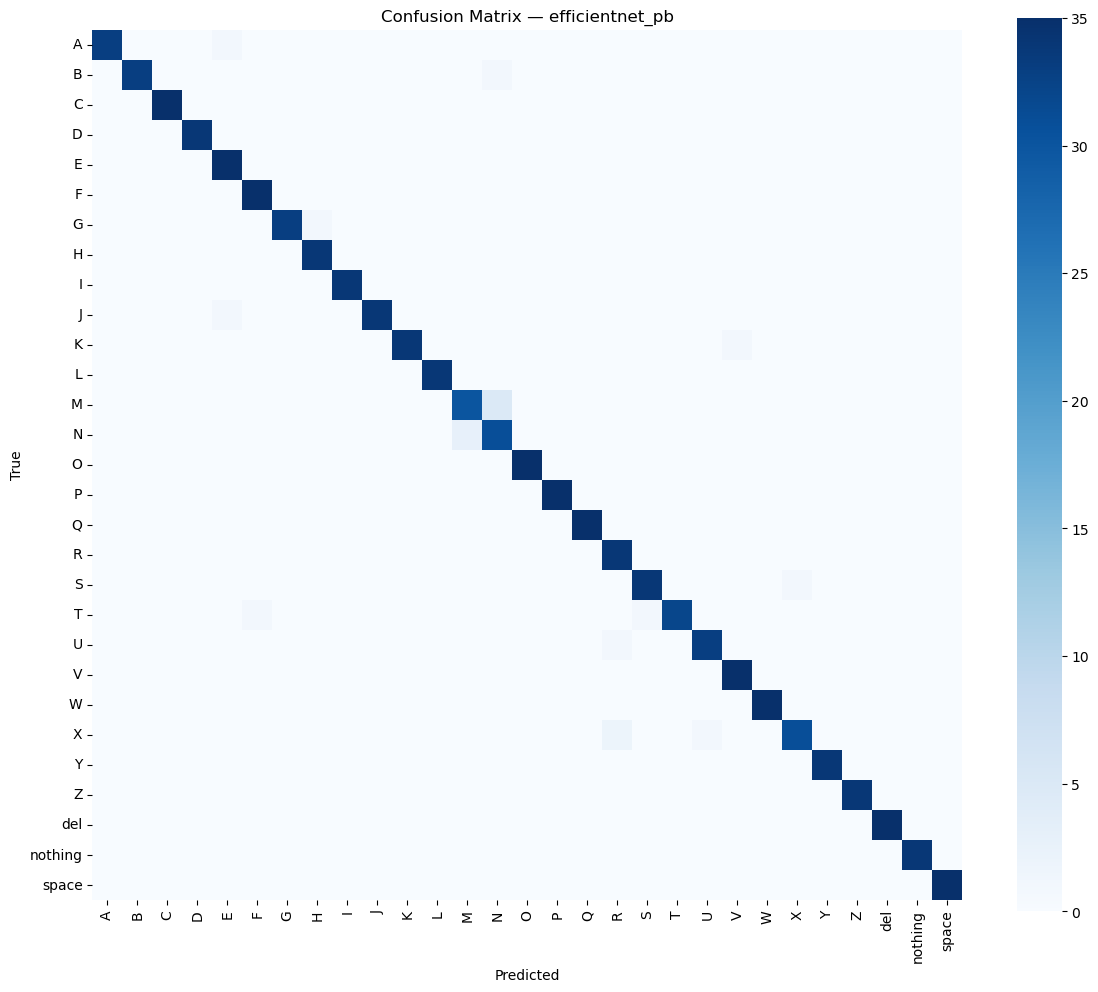


Model: inception (G:\project ai\models\inception.h5)
Using 1000 samples (random class order + random image per class)
Sampled class preview: ['B', 'M', 'Z', 'Q', 'E', 'D', 'L', 'space', 'C', 'R', 'O', 'T', 'nothing', 'I', 'del', 'W', 'V', 'A', 'J', 'H']


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 776ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 812ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 773ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 769ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 736ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 732ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 732ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 830ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 895ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 786ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 766ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

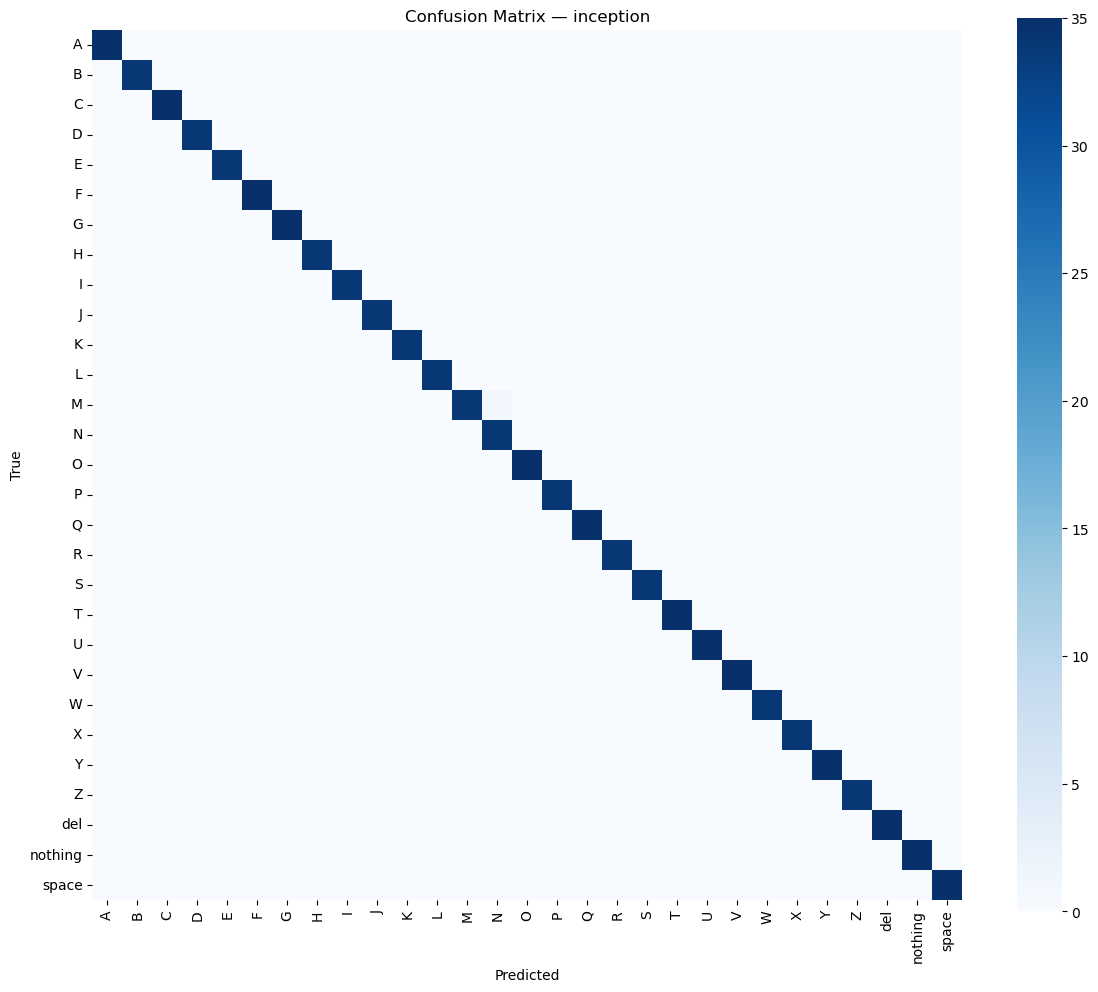


Model: resnet (G:\project ai\models\resnet.h5)
Using 1000 samples (random class order + random image per class)
Sampled class preview: ['Y', 'A', 'T', 'del', 'N', 'K', 'D', 'F', 'O', 'H', 'Z', 'V', 'X', 'W', 'R', 'nothing', 'space', 'E', 'J', 'I']
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/

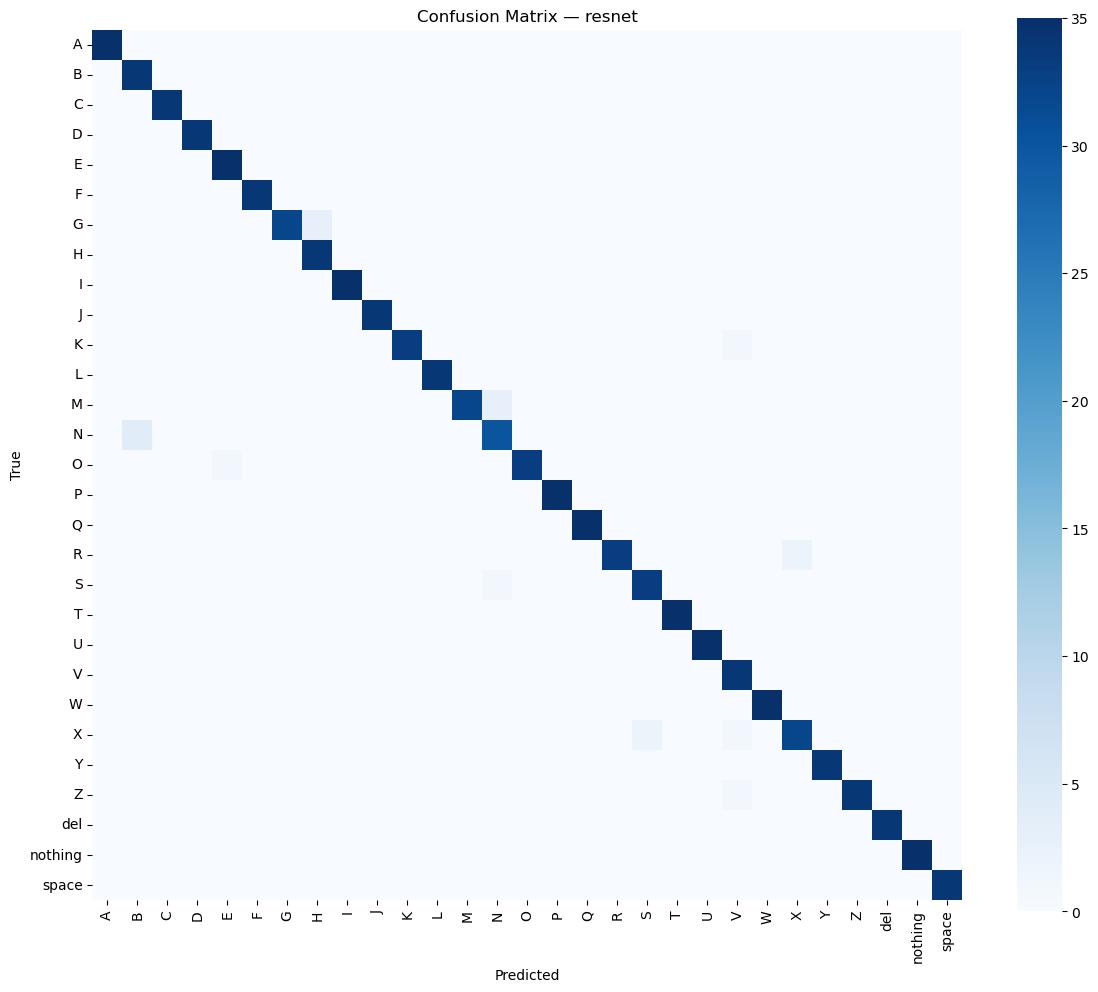

,model,accuracy,precision_macro,recall_macro,n_samples
1,inception,0.999,0.999015,0.999015,1000
2,resnet,0.981,0.981765,0.981078,1000
0,efficientnet_pb,0.980,0.980636,0.979948,1000


In [44]:
# Evaluation on asl_alphabet_train subset (no training)
results_df = pd.DataFrame()

if not EVAL_DIR.exists():
    print(f'Missing eval dir: {EVAL_DIR}')
elif 'MODEL_SPECS' not in globals() or not MODEL_SPECS:
    print(f'No models found under {MODELS_DIR}')
else:
    results = []
    for model_key, spec in MODEL_SPECS.items():
        print('\n' + '=' * 80)
        print(f"Model: {model_key} ({spec['path']})")

        # Load model
        model_obj = None
        if spec['type'] == 'pb':
            model_obj = load_efficientnet_pb(MODELS_DIR)
        else:
            model_obj = load_model(spec['path'], compile=False)

        image_size = (224, 224)
        base_ds, ds_class_names = make_dataset(
            EVAL_DIR,
            image_size=image_size,
            batch_size=BATCH_SIZE,
            shuffle=True,
            shuffle_seed=SHUFFLE_SEED,
            max_images=MAX_IMAGES,
            ensure_class_mix=True,
        )
        if MAX_IMAGES is not None:
            print(f'Using {MAX_IMAGES} samples (random class order + random image per class)')
            y_preview = []
            for _, yb in base_ds.take(1):
                y_preview = yb.numpy().astype(int).ravel().tolist()
            if y_preview:
                preview_labels = [ds_class_names[i] for i in y_preview[: min(20, len(y_preview))]]
                print('Sampled class preview:', preview_labels)

        # Compute y_true and predictions in ONE pass to keep them aligned.
        ds = dataset_with_preprocess(base_ds, model_key, model_obj=model_obj)
        y_true_batches: list[np.ndarray] = []
        y_prob_batches: list[np.ndarray] = []
        for x_batch, y_batch in ds:
            probs = model_obj.predict(x_batch.numpy()) if hasattr(model_obj, 'predict') else model_obj(x_batch, training=False)
            if isinstance(probs, (list, tuple)):
                probs = probs[0]
            probs = tf.convert_to_tensor(probs)
            y_true_batches.append(y_batch.numpy())
            y_prob_batches.append(probs.numpy())

        if not y_true_batches or not y_prob_batches:
            print('No data produced by dataset; skipping.')
            continue

        y_true = np.concatenate(y_true_batches, axis=0).astype(int).ravel()
        y_pred_probs = np.concatenate(y_prob_batches, axis=0)

        if y_pred_probs.ndim != 2:
            print(f'Skipping metrics: model output has shape {y_pred_probs.shape} (expected (N, C)).')
            continue
        if y_pred_probs.shape[1] != len(ds_class_names):
            print('Skipping metrics: model output classes do not match dataset classes.')
            print(f"Model output shape: {y_pred_probs.shape}, classes in dataset: {len(ds_class_names)}")
            continue

        y_pred = np.argmax(y_pred_probs, axis=1).astype(int).ravel()

        preview = min(10, len(y_true))
        for i in range(preview):
            print('True:', ds_class_names[y_true[i]], 'Pred:', ds_class_names[y_pred[i]])

        try:
            acc = float(accuracy_score(y_true, y_pred))
            prec = float(precision_score(y_true, y_pred, average='macro', zero_division=0))
            rec = float(recall_score(y_true, y_pred, average='macro', zero_division=0))
        except ValueError as e:
            print('Metric error:', e)
            print('y_true unique:', np.unique(y_true))
            print('y_pred unique:', np.unique(y_pred))
            continue
        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(ds_class_names))))

        print({'accuracy': acc, 'precision_macro': prec, 'recall_macro': rec, 'n_samples': int(len(y_true))})
        results.append({
            'model': model_key,
            'accuracy': acc,
            'precision_macro': prec,
            'recall_macro': rec,
            'n_samples': int(len(y_true)),
        })

        plt.figure(figsize=(12, 10))
        if sns is not None:
            sns.heatmap(cm, cmap='Blues', square=True, xticklabels=ds_class_names, yticklabels=ds_class_names)
        else:
            plt.imshow(cm, cmap='Blues')
            plt.colorbar()
            plt.xticks(range(len(ds_class_names)), ds_class_names, rotation=90)
            plt.yticks(range(len(ds_class_names)), ds_class_names)
        plt.title(f'Confusion Matrix — {model_key}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.show()

    results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
results_df

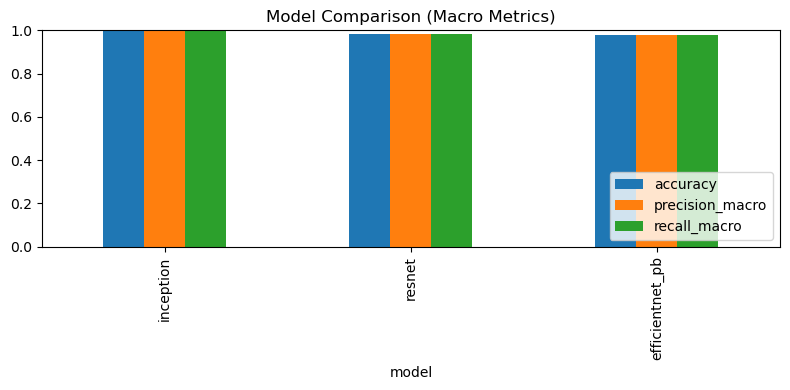

In [45]:
# Comparison plot
if 'results_df' not in globals() or results_df is None or results_df.empty:
    print('No results to compare yet.')
else:
    ax = results_df.set_index('model')[['accuracy', 'precision_macro', 'recall_macro']].plot(kind='bar', figsize=(8, 4))
    ax.set_title('Model Comparison (Macro Metrics)')
    ax.set_ylim(0, 1)
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()